# LIBRERIE

In [ ]:
!pip install pyLDAvis

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 51.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 65.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 77.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.22.4
    Uninstalling numpy-1.22.4:
      Successfully uninstalled numpy-1.22.4
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.3
    Uninstalling pandas-1.5.3:
      Successfully uninstalled pandas-1.5.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==1.5.3, but you have pandas 2.0.2 which is incompatible.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 1.24.3 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import pyLDAvis
import matplotlib.pyplot as plt
from tqdm import tqdm
tqdm.pandas()

# Moduli per eseguire il preprocessing dei testi
import nltk
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from gensim.models.phrases import Phrases
from nltk.corpus import stopwords

from gensim.models.phrases import Phrases
import pyLDAvis.gensim_models as gensimvis
from gensim.models.ldamodel import LdaModel


# Moduli per i modelli vettoriali
import tensorflow as tf
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.model_selection import GridSearchCV

# Moduli per i modelli di classificazione
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

SEED = 42

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
/usr/local/lib/python3.10/dist-packages/google/rpc/__init__.py:20: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.rpc')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  pkg_resources.declare_namespace(__name__)
/usr/local/lib/python3.10/dist-packages/pkg_resources/__init__.py:2349: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/lat

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/pexpect/popen_spawn.py:60: DeprecationWarning: setDaemon() is deprecated, set the daemon attribute instead
  self._read_thread.setDaemon(True)


Mounted at /content/drive


# IMPORTO DATI

Importiamo il dataset, sostituiamo i valori mancanti con la stringa 'Unknown', rendiamo la variabile 'Book_genres' come una lista di valori dato che veniva letta come un dizionario; infine eliminamo due variabili id che saranno inutili per il proseguimento del lavoro.

In [ ]:
import json
book= pd.read_csv('/content/drive/MyDrive/MEGNA - TRIP - ROSCIO/booksummaries.txt', sep='\t', names=['Wikipedia_article_ID', 'Freebase_ID', 'Book_title', 'Author', 'Publication_date', 'Book_genres','Plot_summary'])
book.Author = book.Author.fillna('Unknown')
book.Publication_date = book.Publication_date.fillna('Unknown')
book['Book_genres'] = book.Book_genres.fillna('{"/m/016lj8": "Unknown"}')

try:
    book['Book_genres'] = book['Book_genres'].map(lambda Book_genres : list(json.loads(Book_genres).values()))
except TypeError:
    print("Already converted to list.")

data = book
data = data.drop(columns = ['Wikipedia_article_ID', 'Freebase_ID'])


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
data

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Book_title,Author,Publication_date,Book_genres,Plot_summary
0,Animal Farm,George Orwell,1945-08-17,"[Roman à clef, Satire, Children's literature, ...","Old Major, the old boar on the Manor Farm, ca..."
1,A Clockwork Orange,Anthony Burgess,1962,"[Science Fiction, Novella, Speculative fiction...","Alex, a teenager living in near-future Englan..."
2,The Plague,Albert Camus,1947,"[Existentialism, Fiction, Absurdist fiction, N...",The text of The Plague is divided into five p...
3,An Enquiry Concerning Human Understanding,David Hume,Unknown,[Unknown],The argument of the Enquiry proceeds by a ser...
4,A Fire Upon the Deep,Vernor Vinge,Unknown,"[Hard science fiction, Science Fiction, Specul...",The novel posits that space around the Milky ...
...,...,...,...,...,...
16554,Under Wildwood,Colin Meloy,2012-09-25,[Unknown],"Prue McKeel, having rescued her brother from ..."
16555,Transfer of Power,Vince Flynn,2000-06-01,"[Thriller, Fiction]",The reader first meets Rapp while he is doing...
16556,Decoded,Jay-Z,2010-11-16,[Autobiography],The book follows very rough chronological ord...
16557,America Again: Re-becoming The Greatness We Ne...,Stephen Colbert,2012-10-02,[Unknown],Colbert addresses topics including Wall Stree...


Grafico dei generi più presenti

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


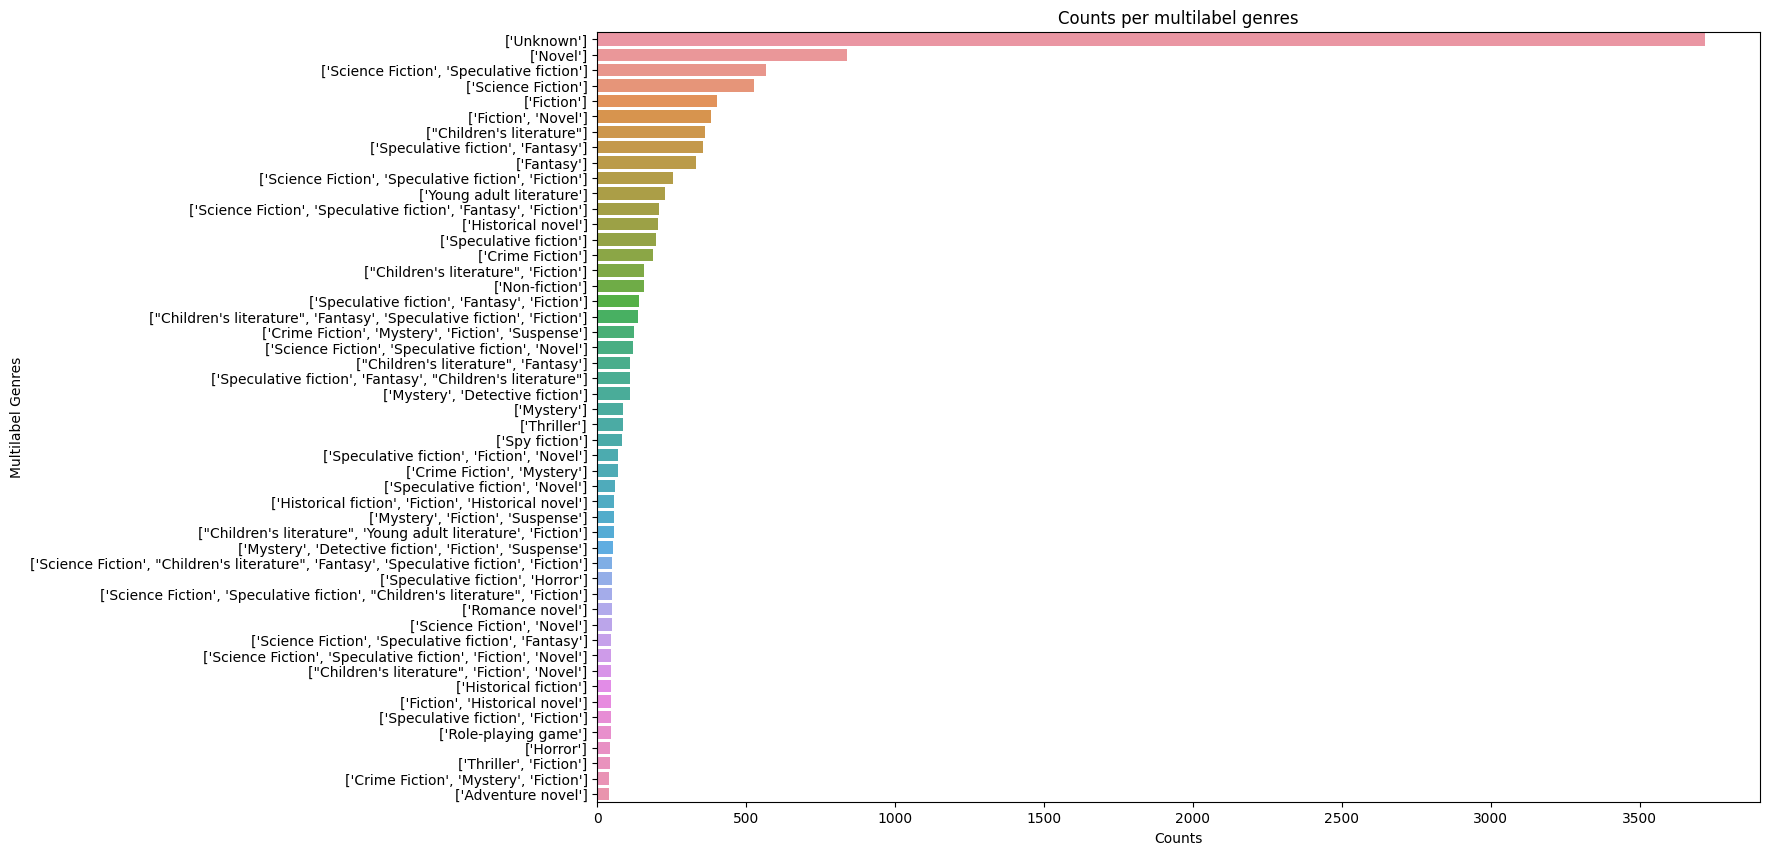

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = {}
g = book['Book_genres'].map(str).to_numpy()
for i in g:
    #''.join(map(lambda x: chr(ord(x) + 1), sampleStr))
    #gn = ' '.join(map(lambda x: str(x) + ' |', i))
    if i in counts.keys():
        counts[i] += 1
    else:
        counts[i] = 1
df = pd.DataFrame({"Genre": list(counts.keys()),
                   "Counts": list(counts.values())})
#elimino i valori unknown per il grafico
#df = df.drop(df[df['Genre'] == '[\'Unknown\']'].index)
df.drop(columns=['Genre'])
g = df.nlargest(columns=["Counts"], n=50)
plt.figure(figsize=(15,10))
ax = sns.barplot(data=g, x= "Counts", y = "Genre")
ax.set(xlabel = 'Counts', ylabel = 'Multilabel Genres')
plt.title('Counts per multilabel genres')
plt.show()

# Pulizia testi


In questa fase andiamo a pulire i testi cercando di mantenere solo le parole che riteniamo più utili per il modello. Andiamo a:

1) rimuovere tutti i carattere non alfa-numerici, caratteri minuscoli

2) rimuoviamo le stopwords

3) eseguiamo una lemmatizzazione e stemming sulle parole

4) rimuoviamo le parole composte da una sola lettera

4) creiamo degli n-gramms

5) rimuoviamo i tf-idf sotto una certa soglia

# 1) rimuovere tutti i carattere non alfa-numerici, caratteri minuscoli

In [ ]:
# Usiamo le espessioni regolari per eliminari tutti i carattere non alfa-numerici
# \d tiene anche i caratteri numerici
data['clear_text'] = data['Plot_summary'].str.lower().str.replace('[^\w\s\d]',' ', regex=True)
data['clear_text'] = data['clear_text'].str.split()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<>:3: DeprecationWarning: invalid escape sequence '\w'
<>:3: DeprecationWarning: invalid escape sequence '\w'
<ipython-input-6-78b73265fbff>:3: DeprecationWarning: invalid escape sequence '\w'
  data['clear_text'] = data['Plot_summary'].str.lower().str.replace('[^\w\s\d]',' ', regex=True)


Creiamo una variabile dopo ogni passaggio di pulizia per verificare quanto diminuiscono le dimensioni dei testi.

In [ ]:
data['len_parole'] = data.clear_text.str.len()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
data

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Book_title,Author,Publication_date,Book_genres,Plot_summary,clear_text,len_parole
0,Animal Farm,George Orwell,1945-08-17,"[Roman à clef, Satire, Children's literature, ...","Old Major, the old boar on the Manor Farm, ca...","[old, major, the, old, boar, on, the, manor, f...",955
1,A Clockwork Orange,Anthony Burgess,1962,"[Science Fiction, Novella, Speculative fiction...","Alex, a teenager living in near-future Englan...","[alex, a, teenager, living, in, near, future, ...",1036
2,The Plague,Albert Camus,1947,"[Existentialism, Fiction, Absurdist fiction, N...",The text of The Plague is divided into five p...,"[the, text, of, the, plague, is, divided, into...",1132
3,An Enquiry Concerning Human Understanding,David Hume,Unknown,[Unknown],The argument of the Enquiry proceeds by a ser...,"[the, argument, of, the, enquiry, proceeds, by...",2894
4,A Fire Upon the Deep,Vernor Vinge,Unknown,"[Hard science fiction, Science Fiction, Specul...",The novel posits that space around the Milky ...,"[the, novel, posits, that, space, around, the,...",736
...,...,...,...,...,...,...,...
16554,Under Wildwood,Colin Meloy,2012-09-25,[Unknown],"Prue McKeel, having rescued her brother from ...","[prue, mckeel, having, rescued, her, brother, ...",154
16555,Transfer of Power,Vince Flynn,2000-06-01,"[Thriller, Fiction]",The reader first meets Rapp while he is doing...,"[the, reader, first, meets, rapp, while, he, i...",213
16556,Decoded,Jay-Z,2010-11-16,[Autobiography],The book follows very rough chronological ord...,"[the, book, follows, very, rough, chronologica...",318
16557,America Again: Re-becoming The Greatness We Ne...,Stephen Colbert,2012-10-02,[Unknown],Colbert addresses topics including Wall Stree...,"[colbert, addresses, topics, including, wall, ...",20


#2) rimuoviamo le stopwords

In [ ]:
# Rimuoviamo le stopwords e ricostruiamo il testo
stop = stopwords.words('english')
stop.extend(['good', 'bad', 'dont', 'many', 'excellent', 'would', 'perfect', 'even', 'great','nice', 'amazing'])
data['clear_text'] = data['clear_text'].progress_apply(lambda x: ' '.join([item for item in x if item not in stop]))

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
100%|██████████| 16559/16559 [00:09<00:00, 1669.77it/s]


In [ ]:
data['clear_text'] = data['clear_text'].str.split()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
data['len_parole_stop'] = data.clear_text.str.len()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
data

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Book_title,Author,Publication_date,Book_genres,Plot_summary,clear_text,len_parole,len_parole_stop
0,Animal Farm,George Orwell,1945-08-17,"[Roman à clef, Satire, Children's literature, ...","Old Major, the old boar on the Manor Farm, ca...","[old, major, old, boar, manor, farm, calls, an...",955,533
1,A Clockwork Orange,Anthony Burgess,1962,"[Science Fiction, Novella, Speculative fiction...","Alex, a teenager living in near-future Englan...","[alex, teenager, living, near, future, england...",1036,587
2,The Plague,Albert Camus,1947,"[Existentialism, Fiction, Absurdist fiction, N...",The text of The Plague is divided into five p...,"[text, plague, divided, five, parts, town, ora...",1132,609
3,An Enquiry Concerning Human Understanding,David Hume,Unknown,[Unknown],The argument of the Enquiry proceeds by a ser...,"[argument, enquiry, proceeds, series, incremen...",2894,1479
4,A Fire Upon the Deep,Vernor Vinge,Unknown,"[Hard science fiction, Science Fiction, Specul...",The novel posits that space around the Milky ...,"[novel, posits, space, around, milky, way, div...",736,431
...,...,...,...,...,...,...,...,...
16554,Under Wildwood,Colin Meloy,2012-09-25,[Unknown],"Prue McKeel, having rescued her brother from ...","[prue, mckeel, rescued, brother, dowager, gove...",154,85
16555,Transfer of Power,Vince Flynn,2000-06-01,"[Thriller, Fiction]",The reader first meets Rapp while he is doing...,"[reader, first, meets, rapp, covert, operation...",213,115
16556,Decoded,Jay-Z,2010-11-16,[Autobiography],The book follows very rough chronological ord...,"[book, follows, rough, chronological, order, s...",318,155
16557,America Again: Re-becoming The Greatness We Ne...,Stephen Colbert,2012-10-02,[Unknown],Colbert addresses topics including Wall Stree...,"[colbert, addresses, topics, including, wall, ...",20,16


#3) eseguiamo una stemming+lemmatizzazione sulle parole

In [ ]:
# Eseguiamo lo stemming ed in seguito la lemmatizzazione
lemmatizer = WordNetLemmatizer()
stemmer= PorterStemmer()

data['clear_text'] = data['clear_text'].progress_apply(lambda x: [stemmer.stem(word) for word in x])
data['clear_text'] = data['clear_text'].progress_apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
data['clear_text'] = data['clear_text'].progress_apply(lambda x: [word for word in x if len(word) > 1])
data

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
100%|██████████| 16559/16559 [00:01<00:00, 14010.24it/s]


,Book_title,Author,Publication_date,Book_genres,Plot_summary,clear_text,len_parole,len_parole_stop
0,Animal Farm,George Orwell,1945-08-17,"[Roman à clef, Satire, Children's literature, ...","Old Major, the old boar on the Manor Farm, ca...","[old, major, old, boar, manor, farm, call, ani...",955,533
1,A Clockwork Orange,Anthony Burgess,1962,"[Science Fiction, Novella, Speculative fiction...","Alex, a teenager living in near-future Englan...","[alex, teenag, live, near, futur, england, lea...",1036,587
2,The Plague,Albert Camus,1947,"[Existentialism, Fiction, Absurdist fiction, N...",The text of The Plague is divided into five p...,"[text, plagu, divid, five, part, town, oran, t...",1132,609
3,An Enquiry Concerning Human Understanding,David Hume,Unknown,[Unknown],The argument of the Enquiry proceeds by a ser...,"[argument, enquiri, proce, seri, increment, st...",2894,1479
4,A Fire Upon the Deep,Vernor Vinge,Unknown,"[Hard science fiction, Science Fiction, Specul...",The novel posits that space around the Milky ...,"[novel, posit, space, around, milki, way, divi...",736,431
...,...,...,...,...,...,...,...,...
16554,Under Wildwood,Colin Meloy,2012-09-25,[Unknown],"Prue McKeel, having rescued her brother from ...","[prue, mckeel, rescu, brother, dowag, gover, c...",154,85
16555,Transfer of Power,Vince Flynn,2000-06-01,"[Thriller, Fiction]",The reader first meets Rapp while he is doing...,"[reader, first, meet, rapp, covert, oper, iran...",213,115
16556,Decoded,Jay-Z,2010-11-16,[Autobiography],The book follows very rough chronological ord...,"[book, follow, rough, chronolog, order, switch...",318,155
16557,America Again: Re-becoming The Greatness We Ne...,Stephen Colbert,2012-10-02,[Unknown],Colbert addresses topics including Wall Stree...,"[colbert, address, topic, includ, wall, street...",20,16


In [ ]:
data['len_parole_lemma'] = data.clear_text.str.len()
data

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Book_title,Author,Publication_date,Book_genres,Plot_summary,clear_text,len_parole,len_parole_stop,len_parole_lemma
0,Animal Farm,George Orwell,1945-08-17,"[Roman à clef, Satire, Children's literature, ...","Old Major, the old boar on the Manor Farm, ca...","[old, major, old, boar, manor, farm, call, ani...",955,533,530
1,A Clockwork Orange,Anthony Burgess,1962,"[Science Fiction, Novella, Speculative fiction...","Alex, a teenager living in near-future Englan...","[alex, teenag, live, near, futur, england, lea...",1036,587,583
2,The Plague,Albert Camus,1947,"[Existentialism, Fiction, Absurdist fiction, N...",The text of The Plague is divided into five p...,"[text, plagu, divid, five, part, town, oran, t...",1132,609,609
3,An Enquiry Concerning Human Understanding,David Hume,Unknown,[Unknown],The argument of the Enquiry proceeds by a ser...,"[argument, enquiri, proce, seri, increment, st...",2894,1479,1459
4,A Fire Upon the Deep,Vernor Vinge,Unknown,"[Hard science fiction, Science Fiction, Specul...",The novel posits that space around the Milky ...,"[novel, posit, space, around, milki, way, divi...",736,431,431
...,...,...,...,...,...,...,...,...,...
16554,Under Wildwood,Colin Meloy,2012-09-25,[Unknown],"Prue McKeel, having rescued her brother from ...","[prue, mckeel, rescu, brother, dowag, gover, c...",154,85,85
16555,Transfer of Power,Vince Flynn,2000-06-01,"[Thriller, Fiction]",The reader first meets Rapp while he is doing...,"[reader, first, meet, rapp, covert, oper, iran...",213,115,114
16556,Decoded,Jay-Z,2010-11-16,[Autobiography],The book follows very rough chronological ord...,"[book, follow, rough, chronolog, order, switch...",318,155,149
16557,America Again: Re-becoming The Greatness We Ne...,Stephen Colbert,2012-10-02,[Unknown],Colbert addresses topics including Wall Stree...,"[colbert, address, topic, includ, wall, street...",20,16,16


#4) ngram

abbiamo utilizzato i bigram, ovvero coppie di parole consecutive.

In [ ]:
bigram_model = Phrases(data['clear_text'], min_count=5, threshold=0.2)
data['clear_text'] = data['clear_text'].progress_apply(lambda x: bigram_model[bigram_model[x]])
data

# min_count=5 significa che gli n-grammi (in questo caso bigrammi) che compaiono meno di 5 volte
# nel corpus di testo saranno scartati.

# threshold=0.2 significa che i bigrammi che hanno una frequenza di co-occorrenza superiore al 20%
# rispetto alla loro singola frequenza verranno considerati come unico termine.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
100%|██████████| 16559/16559 [00:12<00:00, 1291.27it/s]


,Book_title,Author,Publication_date,Book_genres,Plot_summary,clear_text,len_parole,len_parole_stop,len_parole_lemma
0,Animal Farm,George Orwell,1945-08-17,"[Roman à clef, Satire, Children's literature, ...","Old Major, the old boar on the Manor Farm, ca...","[old, major, old, boar, manor, farm, call, ani...",955,533,530
1,A Clockwork Orange,Anthony Burgess,1962,"[Science Fiction, Novella, Speculative fiction...","Alex, a teenager living in near-future Englan...","[alex, teenag_live, near_futur, england, lead,...",1036,587,583
2,The Plague,Albert Camus,1947,"[Existentialism, Fiction, Absurdist fiction, N...",The text of The Plague is divided into five p...,"[text, plagu, divid_five, part_town, oran, tho...",1132,609,609
3,An Enquiry Concerning Human Understanding,David Hume,Unknown,[Unknown],The argument of the Enquiry proceeds by a ser...,"[argument, enquiri, proce, seri, increment, st...",2894,1479,1459
4,A Fire Upon the Deep,Vernor Vinge,Unknown,"[Hard science fiction, Science Fiction, Specul...",The novel posits that space around the Milky ...,"[novel, posit, space, around, milki_way, divid...",736,431,431
...,...,...,...,...,...,...,...,...,...
16554,Under Wildwood,Colin Meloy,2012-09-25,[Unknown],"Prue McKeel, having rescued her brother from ...","[prue, mckeel, rescu, brother, dowag, gover, c...",154,85,85
16555,Transfer of Power,Vince Flynn,2000-06-01,"[Thriller, Fiction]",The reader first meets Rapp while he is doing...,"[reader_first, meet, rapp, covert_oper, iran, ...",213,115,114
16556,Decoded,Jay-Z,2010-11-16,[Autobiography],The book follows very rough chronological ord...,"[book_follow, rough, chronolog_order, switch, ...",318,155,149
16557,America Again: Re-becoming The Greatness We Ne...,Stephen Colbert,2012-10-02,[Unknown],Colbert addresses topics including Wall Stree...,"[colbert, address, topic_includ, wall_street, ...",20,16,16


In [ ]:
data['len_parole_ngram'] = data.clear_text.str.len()
data

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Book_title,Author,Publication_date,Book_genres,Plot_summary,clear_text,len_parole,len_parole_stop,len_parole_lemma,len_parole_ngram
0,Animal Farm,George Orwell,1945-08-17,"[Roman à clef, Satire, Children's literature, ...","Old Major, the old boar on the Manor Farm, ca...","[old, major, old, boar, manor, farm, call, ani...",955,533,530,439
1,A Clockwork Orange,Anthony Burgess,1962,"[Science Fiction, Novella, Speculative fiction...","Alex, a teenager living in near-future Englan...","[alex, teenag_live, near_futur, england, lead,...",1036,587,583,498
2,The Plague,Albert Camus,1947,"[Existentialism, Fiction, Absurdist fiction, N...",The text of The Plague is divided into five p...,"[text, plagu, divid_five, part_town, oran, tho...",1132,609,609,496
3,An Enquiry Concerning Human Understanding,David Hume,Unknown,[Unknown],The argument of the Enquiry proceeds by a ser...,"[argument, enquiri, proce, seri, increment, st...",2894,1479,1459,1282
4,A Fire Upon the Deep,Vernor Vinge,Unknown,"[Hard science fiction, Science Fiction, Specul...",The novel posits that space around the Milky ...,"[novel, posit, space, around, milki_way, divid...",736,431,431,362
...,...,...,...,...,...,...,...,...,...,...
16554,Under Wildwood,Colin Meloy,2012-09-25,[Unknown],"Prue McKeel, having rescued her brother from ...","[prue, mckeel, rescu, brother, dowag, gover, c...",154,85,85,73
16555,Transfer of Power,Vince Flynn,2000-06-01,"[Thriller, Fiction]",The reader first meets Rapp while he is doing...,"[reader_first, meet, rapp, covert_oper, iran, ...",213,115,114,82
16556,Decoded,Jay-Z,2010-11-16,[Autobiography],The book follows very rough chronological ord...,"[book_follow, rough, chronolog_order, switch, ...",318,155,149,124
16557,America Again: Re-becoming The Greatness We Ne...,Stephen Colbert,2012-10-02,[Unknown],Colbert addresses topics including Wall Stree...,"[colbert, address, topic_includ, wall_street, ...",20,16,16,13


Verifichiamo quanto si è ridotta la lunghezza dei testi

In [ ]:
data.describe()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,len_parole,len_parole_stop,len_parole_lemma,len_parole_ngram
count,16559.000000,16559.000000,16559.000000,16559.000000
mean,437.575518,233.557944,232.802645,194.344163
std,509.715570,266.791564,265.809542,223.787884
min,1.000000,1.000000,1.000000,1.000000
25%,123.000000,67.000000,67.000000,55.000000
50%,269.000000,145.000000,144.000000,120.000000
75%,578.500000,310.000000,309.000000,258.000000
max,10514.000000,5060.000000,5051.000000,4135.000000


Eliminiamo le colonne di lunghezza perchè non ci serviranno più.

In [ ]:
data = data.drop(columns=['len_parole',	'len_parole_stop',	'len_parole_lemma', 'len_parole_ngram'])

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


mostriamo il dataset alla conclusione del preprocessing

In [ ]:
data

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Book_title,Author,Publication_date,Book_genres,Plot_summary,clear_text
0,Animal Farm,George Orwell,1945-08-17,"[Roman à clef, Satire, Children's literature, ...","Old Major, the old boar on the Manor Farm, ca...","[old, major, old, boar, manor, farm, call, ani..."
1,A Clockwork Orange,Anthony Burgess,1962,"[Science Fiction, Novella, Speculative fiction...","Alex, a teenager living in near-future Englan...","[alex, teenag_live, near_futur, england, lead,..."
2,The Plague,Albert Camus,1947,"[Existentialism, Fiction, Absurdist fiction, N...",The text of The Plague is divided into five p...,"[text, plagu, divid_five, part_town, oran, tho..."
3,An Enquiry Concerning Human Understanding,David Hume,Unknown,[Unknown],The argument of the Enquiry proceeds by a ser...,"[argument, enquiri, proce, seri, increment, st..."
4,A Fire Upon the Deep,Vernor Vinge,Unknown,"[Hard science fiction, Science Fiction, Specul...",The novel posits that space around the Milky ...,"[novel, posit, space, around, milki_way, divid..."
...,...,...,...,...,...,...
16554,Under Wildwood,Colin Meloy,2012-09-25,[Unknown],"Prue McKeel, having rescued her brother from ...","[prue, mckeel, rescu, brother, dowag, gover, c..."
16555,Transfer of Power,Vince Flynn,2000-06-01,"[Thriller, Fiction]",The reader first meets Rapp while he is doing...,"[reader_first, meet, rapp, covert_oper, iran, ..."
16556,Decoded,Jay-Z,2010-11-16,[Autobiography],The book follows very rough chronological ord...,"[book_follow, rough, chronolog_order, switch, ..."
16557,America Again: Re-becoming The Greatness We Ne...,Stephen Colbert,2012-10-02,[Unknown],Colbert addresses topics including Wall Stree...,"[colbert, address, topic_includ, wall_street, ..."


# GRID SEARCH LDA

Facciamo una grid search per stimare gli iperparametri più importanti.

In [ ]:
# Viene creato un oggetto Dictionary utilizzando i testi presenti nella colonna 'clear_text'.
#Un dizionario è una mappatura univoca tra le parole nel corpus e un identificatore numerico univoco assegnato a ciascuna parola.
dictionary = corpora.Dictionary(data['clear_text'])
# Il corpus è una rappresentazione dei testi in forma di elenco di coppie (ID della parola, conteggio). Viene creato un corpus utilizzando il dizionario appena creato.
corpus = [dictionary.doc2bow(text) for text in data['clear_text']]
# Usiamo il tf-idf per rappresentare le parole, calcola i pesi TF-IDF per ogni termine nel corpus, assegnando un peso più alto alle parole più importanti e meno frequenti nell'intero corpus.
tfidf = models.TfidfModel(corpus)
# creazione del corpus tf-idf in cui i conteggi vengono sostituiti dai pesi corrispondenti
corpus_tfidf = tfidf[corpus]

In [ ]:
from gensim.models import CoherenceModel
# funzione di supporto
def compute_coherence_values(corpus, dictionary, k, a, b):

    lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=k,
                                           random_state=100,
                                           chunksize=100,
                                           passes=3,
                                           alpha=a,
                                           eta=b)

    coherence_model_lda = CoherenceModel(model=lda_model, texts=data['clear_text'], dictionary=dictionary, coherence='c_v')

    return coherence_model_lda.get_coherence()

Nel codice qui sotto i topic sono impostati da 1 a 25, in realtà li abbiamo eseguiti in tre momenti diversi, prima da 1 a 11, poi da 11 a 20 e infine da 20 a 25 per ridurre il tempo di esecuzione e per 'stressare' meno la macchina.

In [ ]:
grid = {}
grid['Validation_Set'] = {}

# Topics range
min_topics = 1
max_topics = 25
step_size = 1
topics_range = range(min_topics, max_topics, step_size)

# Alpha parameter
alpha = list(np.arange(0.01, 1, 0.3))
alpha.append('symmetric')
alpha.append('asymmetric')

# Beta parameter
beta = list(np.arange(0.01, 1, 0.3))
beta.append('symmetric')

# Validation sets
num_of_docs = len(corpus)
corpus_sets = [gensim.utils.ClippedCorpus(corpus, int(num_of_docs*0.75)),
               corpus]

corpus_title = ['75% Corpus', '100% Corpus']

model_results = {'Validation_Set': [],
                 'Topics': [],
                 'Alpha': [],
                 'Beta': [],
                 'Coherence': []
                }

# Can take a long time to run
if 1 == 1:
    pbar = tqdm.tqdm(total=(len(beta)*len(alpha)*len(topics_range)*len(corpus_title)))

    # iterate through validation corpuses
    for i in range(len(corpus_sets)):
        # iterate through number of topics
        for k in topics_range:
            # iterate through alpha values
            for a in alpha:
                # iterare through beta values
                for b in beta:
                    # get the coherence score for the given parameters
                    cv = compute_coherence_values(corpus=corpus_sets[i], dictionary=dictionary,
                                                  k=k, a=a, b=b)
                    # Save the model results
                    model_results['Validation_Set'].append(corpus_title[i])
                    model_results['Topics'].append(k)
                    model_results['Alpha'].append(a)
                    model_results['Beta'].append(b)
                    model_results['Coherence'].append(cv)

                    pbar.update(1)
    pd.DataFrame(model_results).to_csv('/content/drive/MyDrive/MEGNA - TRIP - ROSCIO/lda_tuning_results.csv', index=False)
    pbar.close()

# GRID SEARCH LDA RISULTATI

Controlliamo i risultati unendo i 3 csv e ordinandoli in ordine decrescente

In [ ]:
lda_tuning_results_1_11= pd.read_csv('/content/drive/MyDrive/MEGNA - TRIP - ROSCIO/risultati grid search/lda_tuning_results_1_11.csv', sep=',')
lda_tuning_results_1_11.sort_values(by=['Coherence'], ascending=False)
lda_tuning_results_11_20= pd.read_csv('/content/drive/MyDrive/MEGNA - TRIP - ROSCIO/risultati grid search/lda_tuning_results_11_20.csv', sep=',')
lda_tuning_results_11_20.sort_values(by=['Coherence'], ascending=False)
lda_tuning_results_21_25= pd.read_csv('/content/drive/MyDrive/MEGNA - TRIP - ROSCIO/risultati grid search/lda_results_21_25.csv', sep=',')
lda_tuning_results_21_25.sort_values(by=['Coherence'], ascending=False)

LDA_RESULTS= pd.concat([lda_tuning_results_1_11, lda_tuning_results_11_20, lda_tuning_results_21_25])
#LDA_RESULTS.sort_values(by=['Coherence'], ascending=False)
LDA_RESULTS.sort_values(by=['Coherence'], ascending=False)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,Validation_Set,Topics,Alpha,Beta,Coherence
176,100% Corpus,22,asymmetric,0.31,0.554856
209,100% Corpus,23,asymmetric,symmetric,0.540037
206,100% Corpus,23,asymmetric,0.31,0.539868
177,100% Corpus,22,asymmetric,0.61,0.538248
181,100% Corpus,23,0.01,0.31,0.536913
...,...,...,...,...,...
360,100% Corpus,14,0.01,0.01,0.223490
380,100% Corpus,14,symmetric,0.01,0.223207
410,100% Corpus,15,symmetric,0.01,0.223178
388,100% Corpus,14,asymmetric,0.9099999999999999,0.222028


Vediamo la coherence media per ogni topic

In [ ]:
LDA_RESULTS_best = LDA_RESULTS.groupby('Topics').Coherence.max()
LDA_RESULTS_best

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Topics
2     0.260786
3     0.289832
4     0.296646
5     0.314562
6     0.342662
7     0.446660
8     0.458193
9     0.469665
10    0.476905
11    0.242873
12    0.240637
13    0.256350
14    0.238698
15    0.243934
16    0.263837
17    0.259421
18    0.252357
19    0.257129
21    0.534744
22    0.554856
23    0.540037
24    0.526734
Name: Coherence, dtype: float64

Rappresentiamo la coherence media per vedere come si evolve

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Text(0, 0.5, 'Coherence')

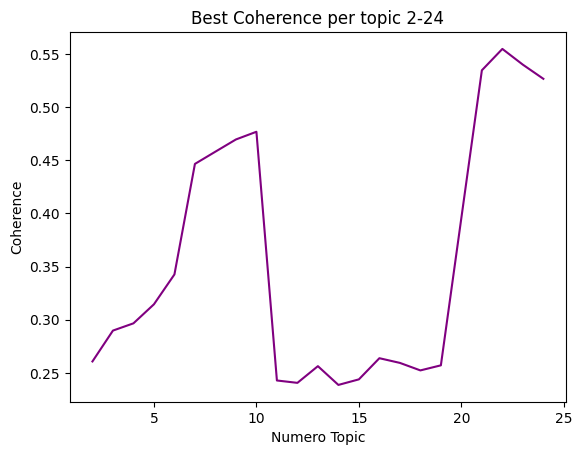

In [ ]:
plt.plot(LDA_RESULTS_best.index, LDA_RESULTS_best,
         color = 'purple')
plt.title('Best Coherence per topic 2-24')
plt.xlabel('Numero Topic')
plt.ylabel('Coherence')

# TOPIC MODELING

A questo punto runniamo il modello con i parametri migliori, in seguito lo salviamo in modo da non dover perdere tempo per runnarlo altre volte.

In [ ]:
from gensim import models, corpora
# Utilizziamo la stessa tecnica usata per la grid search
dictionary = corpora.Dictionary(data['clear_text'])
corpus = [dictionary.doc2bow(text) for text in data['clear_text']]

tfidf = models.TfidfModel(corpus)
corpus_tfidf = tfidf[corpus]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
from time import sleep
from tqdm import tqdm
for i in tqdm(range(10)):
    sleep(0.2)
# Eseguiamo LDA
    num_topics = 22
    ldamodel = LdaModel(corpus, num_topics=num_topics, id2word=dictionary, alpha='asymmetric', eta=0.31, passes=10)
# passes sono le iterazioni
# num_topics il numero di topic scelti per riga

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
100%|██████████| 10/10 [42:03<00:00, 252.40s/it]


In [ ]:
ldamodel.save('modello_finale22.gensim')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


# ANALISI DEI TOPIC

In [ ]:
ldamodel= ldamodel.load('/content/drive/MyDrive/MEGNA - TRIP - ROSCIO/modello 22 topic/modello_finale22.gensim')

In [ ]:
# Vediamo i topic individuati, con le 30 parole più importanti per topic e la loro distribuzione di probabilità
topics = ldamodel.print_topics(num_words=30)
for topic in topics:
    print(topic)

(21, '0.005*"larten" + 0.004*"sooki" + 0.003*"callus" + 0.003*"fang" + 0.003*"dylan" + 0.003*"eric" + 0.003*"seba" + 0.002*"zoe" + 0.002*"hanafi" + 0.002*"flock" + 0.002*"darren" + 0.002*"dee" + 0.001*"wester" + 0.001*"brett" + 0.001*"tintin" + 0.001*"josh" + 0.001*"alcatraz" + 0.001*"frodo" + 0.001*"flamel" + 0.001*"scathach" + 0.001*"jeb" + 0.001*"machiavelli" + 0.001*"danu_talus" + 0.001*"kip" + 0.001*"max" + 0.001*"larten_wester" + 0.001*"perenel" + 0.001*"vampanez" + 0.001*"corwin" + 0.001*"sophi"')
(20, '0.008*"eugeni" + 0.006*"cadfael" + 0.006*"finn" + 0.006*"arthur" + 0.006*"jake" + 0.004*"celia" + 0.004*"valkyri" + 0.004*"dorian" + 0.003*"kiyo" + 0.003*"animorph" + 0.003*"jacob" + 0.003*"rhi" + 0.003*"aeson" + 0.003*"yeerk" + 0.003*"ax" + 0.002*"cassi" + 0.002*"skulduggeri" + 0.002*"morph" + 0.002*"wendi" + 0.002*"marco" + 0.002*"tasha" + 0.002*"lissa" + 0.002*"tobia" + 0.002*"adrian" + 0.002*"elora" + 0.002*"storm_king" + 0.002*"creel" + 0.002*"mina" + 0.001*"dracula" + 0.001

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Associamo a ogni testo il topic più rilevante
res = list()
for t in tqdm(range(0, data.shape[0])):
    topic, rilevance = sorted(ldamodel.get_document_topics(corpus[t]), key=lambda x: -x[1])[0]
    topic_words = [(dictionary[word_ind[0]], word_ind[1])for word_ind in ldamodel.get_topic_terms(topic, topn=10)]
    res.append({'text': ' '.join(data['clear_text'][t]), 'best_topic': topic, 'rilevance': rilevance, 'topic_words': topic_words})
final_topics = pd.DataFrame(res)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
100%|██████████| 16559/16559 [03:02<00:00, 90.73it/s] 


In [ ]:
final_topics

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,text,best_topic,rilevance,topic_words
0,old major old boar manor farm call anim_farm m...,0,0.395515,"[(stori, 0.0021984065), (famili, 0.0021902695)..."
1,alex teenag_live near_futur england lead gang ...,0,0.577599,"[(stori, 0.0021984065), (famili, 0.0021902695)..."
2,text plagu divid_five part_town oran thousand ...,0,0.375041,"[(stori, 0.0021984065), (famili, 0.0021902695)..."
3,argument enquiri proce seri increment step sep...,12,0.683029,"[(christian, 0.0035712735), (argu, 0.003057414..."
4,novel posit space around milki_way divid conce...,3,0.924069,"[(ship, 0.0026267683), (use, 0.002313784), (hu..."
...,...,...,...,...
16554,prue mckeel rescu brother dowag gover conclus ...,6,0.615961,"[(find, 0.0028442382), (kill, 0.0027477066), (..."
16555,reader_first meet rapp covert_oper iran discov...,3,0.932649,"[(ship, 0.0026267683), (use, 0.002313784), (hu..."
16556,book_follow rough chronolog_order switch curre...,0,0.992914,"[(stori, 0.0021984065), (famili, 0.0021902695)..."
16557,colbert address topic_includ wall_street campa...,3,0.652549,"[(ship, 0.0026267683), (use, 0.002313784), (hu..."


In [ ]:
# Visualiziamo come si distribuiscono i topic e i termini più importanti
lda_display = gensimvis.prepare(ldamodel, corpus, dictionary, sort_topics=True)

pyLDAvis.display(lda_display)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
from gensim.models import CoherenceModel

# Calcoliamo la Coherence del modello attraverso il metodo c_v
coherence_model_lda = CoherenceModel(model=ldamodel, texts=data.clear_text, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('Coherence Score: ', coherence_lda)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Coherence Score:  0.47745616218571346


Creiamo il dataset finale che utilizzeremo nella seconda parte per fornire i risultati

In [ ]:
final_topics['Book_title'] = data['Book_title']
final_topics['Author'] = data['Author']
final_topics['Publication_date'] = data['Publication_date']
final_topics['Book_genres'] = data['Book_genres']
final_topics['Plot_summary'] = data['Plot_summary']
final_topics

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,text,best_topic,rilevance,topic_words,Book_title,Author,Publication_date,Book_genres,Plot_summary
0,old major old boar manor farm call anim_farm m...,0,0.395515,"[(stori, 0.0021984065), (famili, 0.0021902695)...",Animal Farm,George Orwell,1945-08-17,"[Roman à clef, Satire, Children's literature, ...","Old Major, the old boar on the Manor Farm, ca..."
1,alex teenag_live near_futur england lead gang ...,0,0.577599,"[(stori, 0.0021984065), (famili, 0.0021902695)...",A Clockwork Orange,Anthony Burgess,1962,"[Science Fiction, Novella, Speculative fiction...","Alex, a teenager living in near-future Englan..."
2,text plagu divid_five part_town oran thousand ...,0,0.375041,"[(stori, 0.0021984065), (famili, 0.0021902695)...",The Plague,Albert Camus,1947,"[Existentialism, Fiction, Absurdist fiction, N...",The text of The Plague is divided into five p...
3,argument enquiri proce seri increment step sep...,12,0.683029,"[(christian, 0.0035712735), (argu, 0.003057414...",An Enquiry Concerning Human Understanding,David Hume,Unknown,[Unknown],The argument of the Enquiry proceeds by a ser...
4,novel posit space around milki_way divid conce...,3,0.924069,"[(ship, 0.0026267683), (use, 0.002313784), (hu...",A Fire Upon the Deep,Vernor Vinge,Unknown,"[Hard science fiction, Science Fiction, Specul...",The novel posits that space around the Milky ...
...,...,...,...,...,...,...,...,...,...
16554,prue mckeel rescu brother dowag gover conclus ...,6,0.615961,"[(find, 0.0028442382), (kill, 0.0027477066), (...",Under Wildwood,Colin Meloy,2012-09-25,[Unknown],"Prue McKeel, having rescued her brother from ..."
16555,reader_first meet rapp covert_oper iran discov...,3,0.932649,"[(ship, 0.0026267683), (use, 0.002313784), (hu...",Transfer of Power,Vince Flynn,2000-06-01,"[Thriller, Fiction]",The reader first meets Rapp while he is doing...
16556,book_follow rough chronolog_order switch curre...,0,0.992914,"[(stori, 0.0021984065), (famili, 0.0021902695)...",Decoded,Jay-Z,2010-11-16,[Autobiography],The book follows very rough chronological ord...
16557,colbert address topic_includ wall_street campa...,3,0.652549,"[(ship, 0.0026267683), (use, 0.002313784), (hu...",America Again: Re-becoming The Greatness We Ne...,Stephen Colbert,2012-10-02,[Unknown],Colbert addresses topics including Wall Stree...


In [ ]:
final_topics.to_csv('/content/drive/MyDrive/MEGNA - TRIP - ROSCIO/modello 5 topic/finale/data_finale22.csv')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
